## **psf_conv.py -- 4 modalities for PSF convolution** ##

This notebook shows the 4 modalities that psf_conv.py handles to generate captured images by convolving with precalculated PSFs:

1) Single metalens [1, grid_N, grid_N], shift invariant PSFs [1, 1, grid_N, grid_N]<br>
    --> captured images: [B, 1, grid_N, grid_N]
2) Metalens array [L, grid_N, grid_N], shift invariant PSFs [L, 1, grid_N, grid_N]<br>
    --> captured images: [B, L, grid_N, grid_N]
3) Single metalens [1, grid_N, grid_N], spatially PSFs [1, P, crop_N, crop_N]<br>
    --> captured images: [B, 1, grid_N, grid_N]
4) Metalens array [L, grid_N, grid_N], spatially PSFs [L, P, crop_N, crop_N]<br>
    --> captured images: [B, L, grid_N, grid_N]

For simplicity and visualization, lens phases used will be hyperbolic and defocused hyperbolic phase profiles. Field of view angle is large (HFOV=30 deg) to easily see large field effects. 

In [1]:
import math
import torch
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append("asm_full_opt")
from phase_mask import PhaseMask
from asm_prop import ASMPropagator
from pixel_map import PixelMap
from psf_conv import PSFConv
from generate_waves_sv import GenerateWaves
from process_psf_sv import PSFProcessor
import config

UM=1e-6

In [2]:
config.GRID_N = 301
config.HFOV=30
config.LENS_D=40*UM
config.PSF_WINDOW_N=75

In [3]:
asm = ASMPropagator(config)
pm = PixelMap(config, asm.X, asm.Y)
conv = PSFConv(config, pm, asm.X, asm.Y)
waves = GenerateWaves(config, pm, X=asm.X, Y=asm.Y)
processor = PSFProcessor(config)

## Make some object targets ##

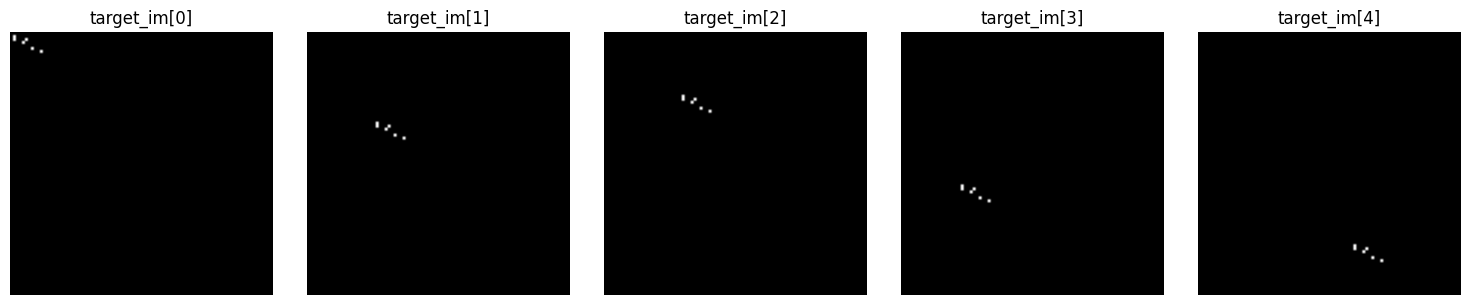

In [4]:
import random

# Build an asymmetric sparse-point target image stack
H = W = 88
B = 5
target_im = torch.zeros((B, 1, H, W), dtype=torch.float32)
# Base top-left corner cluster
pts = [(3, 4),(5, 7),(6, 10),(2, 5),(2, 1),(1, 1),]

for r, c in pts:
    target_im[0, 0, r, c] = 1.0
rows = [r for r, c in pts]
cols = [c for r, c in pts]
min_dr = -min(rows)
max_dr = (H - 1) - max(rows)
min_dc = -min(cols)
max_dc = (W - 1) - max(cols)
# Make images 2-5 by shifting the whole pattern
random.seed(117)  
used_shifts = set([(0, 0)])

for b in range(1, B):
    while True:
        dr = random.randint(min_dr, max_dr)
        dc = random.randint(min_dc, max_dc)
        if (dr, dc) not in used_shifts:
            used_shifts.add((dr, dc))
            break

    for r, c in pts:
        target_im[b, 0, r + dr, c + dc] = 1.0

# Plot all 5 target images
fig, axes = plt.subplots(1, B, figsize=(3 * B, 3))
for b in range(B):
    axes[b].imshow(target_im[b, 0].detach().cpu().numpy(), cmap="gray")
    axes[b].set_title(f"target_im[{b}]")
    axes[b].axis("off")

plt.tight_layout()
plt.show()

objs = target_im

## 1) Single metalens, spatially invariant PSF ##

PSF shape: torch.Size([1, 1, 301, 301])


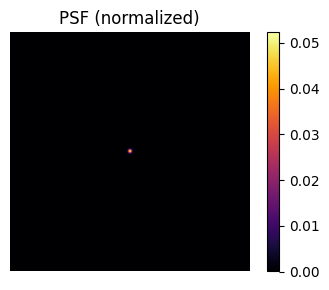

In [5]:
phase = PhaseMask(
    config,
    num_masks=1,
    init="hyperbolic",
    X=asm.X,
    Y=asm.Y,    
    test_orientation=False,
)

with torch.no_grad():
    psf, Uz = asm(phase_mask=phase, normalize=True, return_field=True)

psf0 = psf.detach().cpu()
print("PSF shape:", psf.shape)

plt.figure(figsize=(4, 3))
plt.imshow((psf0[0,0]).T, origin="lower", cmap="inferno")
plt.title("PSF (normalized)")
plt.colorbar()
plt.axis("off")
plt.tight_layout()
plt.show()

captured images: torch.Size([5, 1, 301, 301])


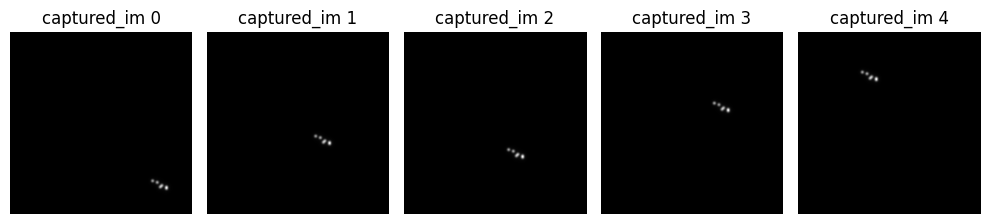

In [6]:
captured_im = conv.sensor_image(objs, psf0)
print("captured images:", captured_im.shape)

im = captured_im.detach().cpu().numpy()

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    ax = axes[i]
    ax.imshow(im[i, 0].T, cmap="gray", origin="lower")
    ax.set_title(f"captured_im {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 2) Multiple metalenses, spatially invariant PSFs ##

PSF shape: torch.Size([3, 1, 301, 301])


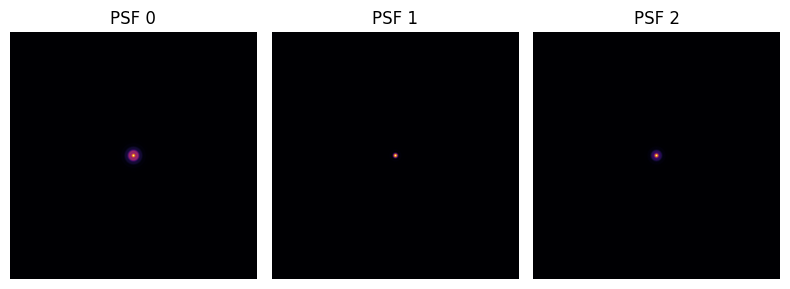

In [7]:
phase_array = PhaseMask(
    config,
    num_masks=3,
    defocus_max=15*UM,
    init="hyperbolic",
    X=asm.X,
    Y=asm.Y,    
    test_orientation=False,
)

with torch.no_grad():
    psf, Uz = asm(phase_mask=phase_array, normalize=True, return_field=True)

psf0 = psf.detach().cpu()
print("PSF shape:", psf.shape)

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for i in range(3):
    ax = axes[i]
    ax.imshow(psf0[i, 0].T, cmap="inferno", origin="lower")
    ax.set_title(f"PSF {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()


captured images: torch.Size([5, 3, 301, 301])


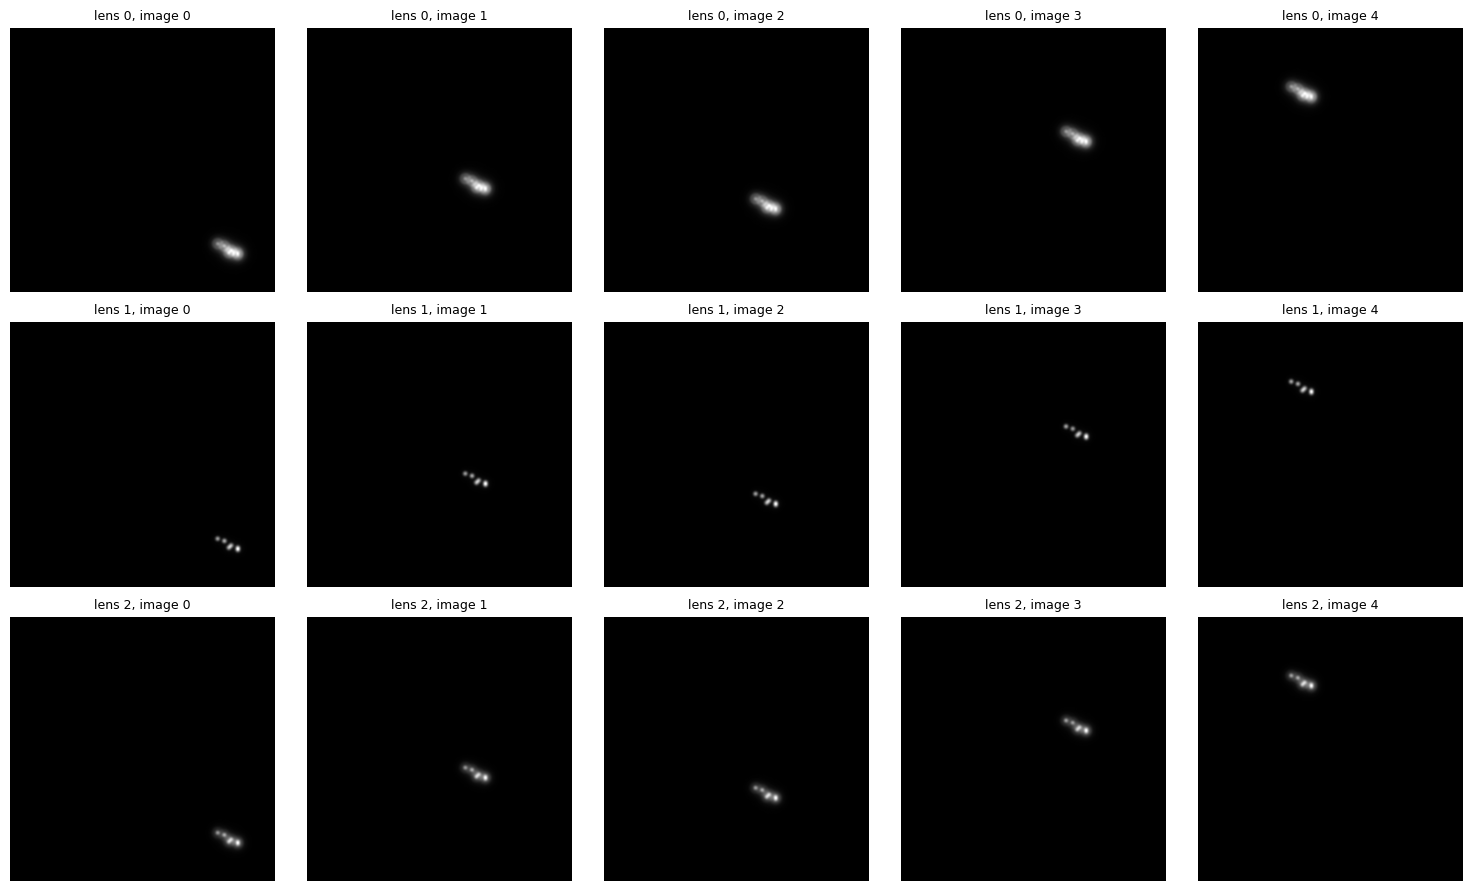

In [8]:
captured_im = conv.sensor_image(objs, psf0)
print("captured images:", captured_im.shape)

im = captured_im.detach().cpu().numpy()

B, L, H, W = im.shape
fig, axes = plt.subplots(L, B, figsize=(3*B, 3*L), squeeze=False)
for b in range(B):
    for l in range(L):
        ax = axes[l, b]
        ax.imshow(im[b, l].T, cmap="gray", origin="lower")
        ax.set_title(f"lens {l}, image {b}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

## 3) Single metalens, spatially varying PSFs ##

PSF shape: torch.Size([1, 16, 75, 75])


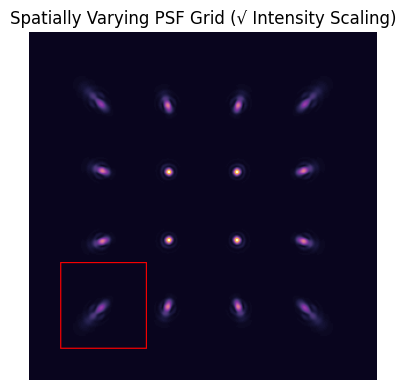

In [9]:
U0 = waves.generate_plane_wave_stack()

with torch.no_grad():
    psfs_sv, _ = asm(phase_mask=phase, U0_stack=U0, normalize=True, return_field=True)

psf_proc = processor(psfs_sv, pm, waves)
conv = PSFConv(config, pm, processor, asm.X, asm.Y)

print("PSF shape:", psf_proc.shape)

view_idx = 0
crops = psf_proc
splat, frame_mask = processor.splat_crops_on_sensor(
    crops,
    pixel_map=pm,
    waves=waves,
    index=view_idx,
    frame_stride=24,
)


splat_np = splat.detach().cpu().numpy()
frame_np = frame_mask.detach().cpu().numpy()
base = np.clip(splat_np, 0, None)
base = base / (base.max() + 1e-12)

# Apply inferno colormap
cmap = plt.cm.inferno
rgb = cmap(base)[..., :3]   # drop alpha channel

# Overlay frames in red
rgb[..., 0] = np.clip(rgb[..., 0] + frame_np, 0, 1)
rgb[..., 1] = np.where(frame_np > 0, 0.0, rgb[..., 1])
rgb[..., 2] = np.where(frame_np > 0, 0.0, rgb[..., 2])

plt.figure(figsize=(5,4))
plt.imshow(np.sqrt(rgb.transpose(1,0,2)))
plt.title("Spatially Varying PSF Grid (√ Intensity Scaling)")
plt.axis("off")
plt.tight_layout()
plt.show()


captured images: torch.Size([5, 1, 301, 301])


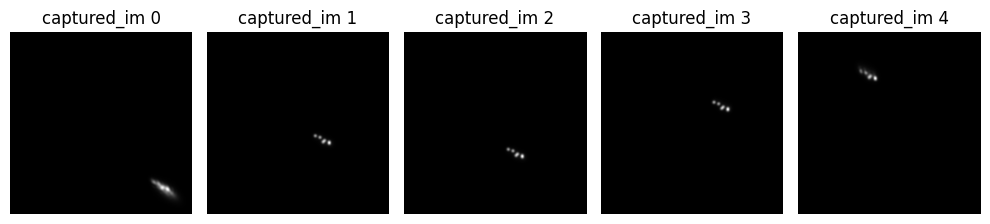

In [10]:
captured_im = conv.sensor_image(objs, psf_proc)
print("captured images:", captured_im.shape)

im = captured_im.detach().cpu().numpy()

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    ax = axes[i]
    ax.imshow(im[i, 0].T, cmap="gray", origin="lower")
    ax.set_title(f"captured_im {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4) Multiple metalenses, spatially varying PSFs ##

PSF shape: torch.Size([3, 16, 75, 75])


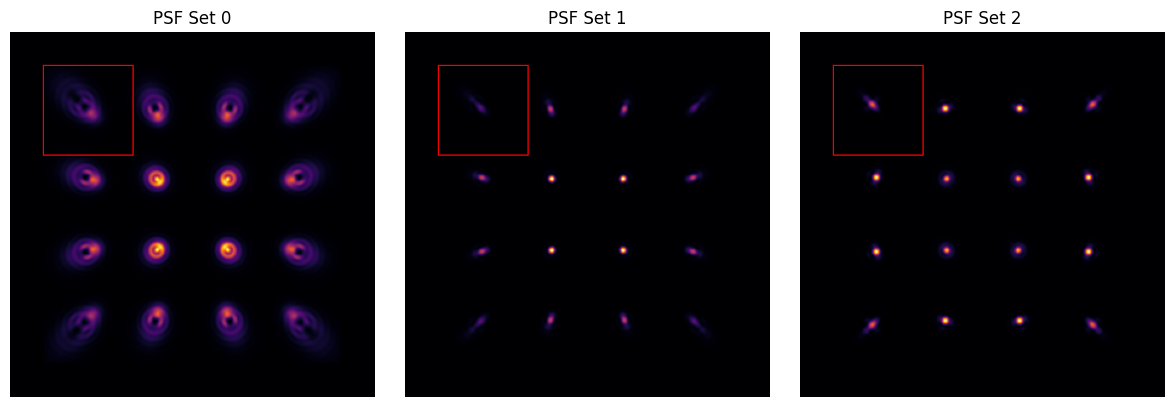

In [11]:
with torch.no_grad():
    psfs_sv, _ = asm(phase_mask=phase_array, U0_stack=U0, normalize=True, return_field=True)

psf_proc = processor(psfs_sv, pm, waves)
conv = PSFConv(config, pm, processor, asm.X, asm.Y)

print("PSF shape:", psf_proc.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):

    crops = psf_proc[i]  # [49, 55, 55]

    splat, frame_mask = processor.splat_crops_on_sensor(
        crops,
        pixel_map=pm,
        waves=waves,
        index=view_idx,
        frame_stride=25,
    )

    splat_np = splat.detach().cpu().numpy()
    frame_np = frame_mask.detach().cpu().numpy()

    base = np.clip(splat_np, 0, None)
    base = base / (base.max() + 1e-12)

    cmap = plt.cm.inferno
    rgb = cmap(base)[..., :3]

    rgb[..., 0] = np.clip(rgb[..., 0] + frame_np, 0, 1)
    rgb[..., 1] = np.where(frame_np > 0, 0.0, rgb[..., 1])
    rgb[..., 2] = np.where(frame_np > 0, 0.0, rgb[..., 2])

    axes[i].imshow(rgb.transpose(1,0,2), origin="lower")
    axes[i].set_title(f"PSF Set {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

captured images: torch.Size([5, 3, 301, 301])


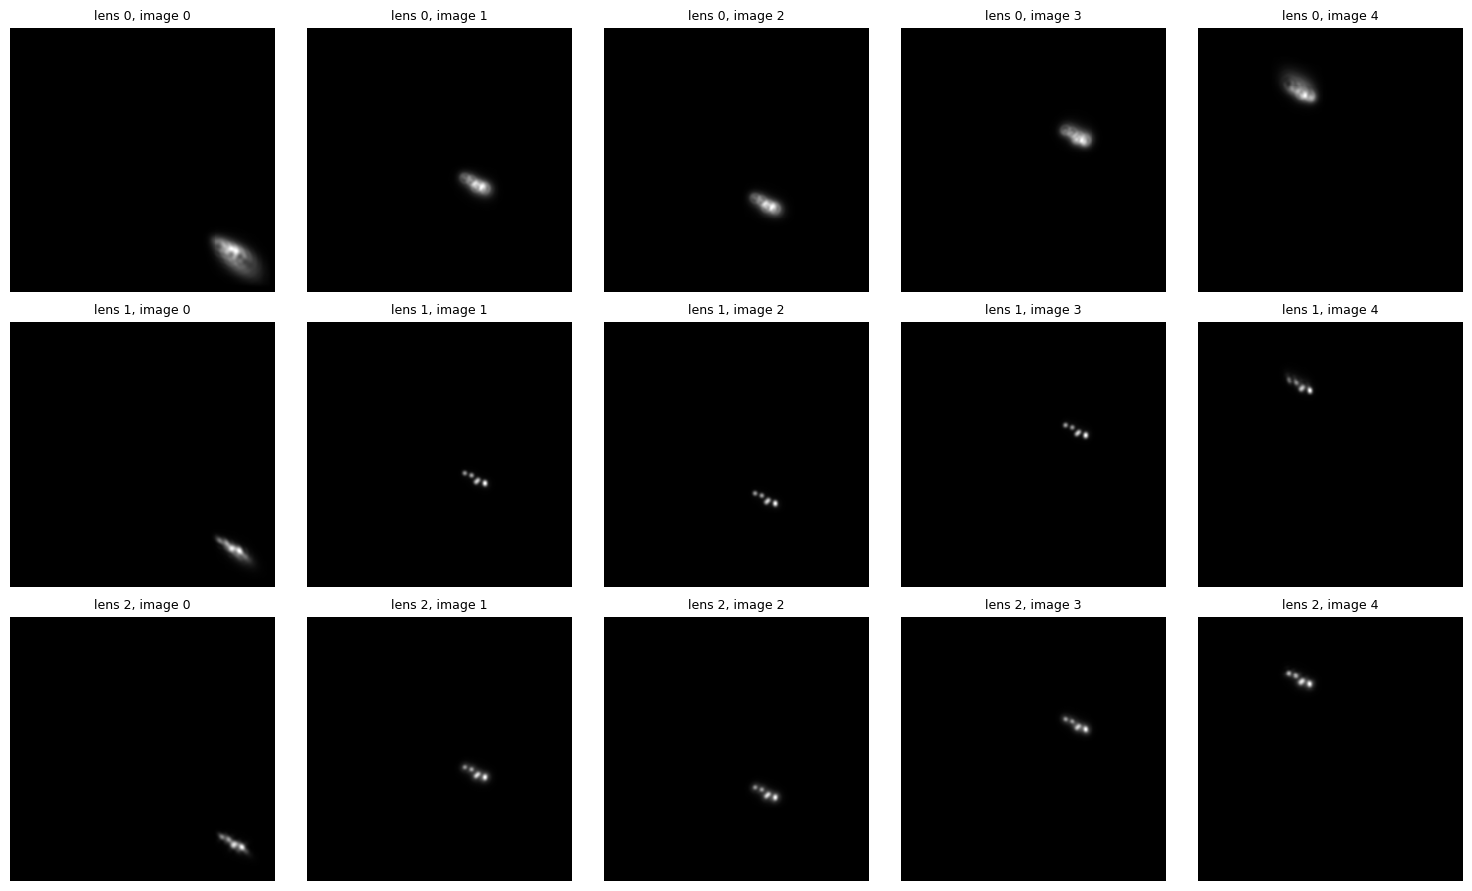

In [12]:
captured_im = conv.sensor_image(objs, psf_proc)
print("captured images:", captured_im.shape)

im = captured_im.detach().cpu().numpy()

B, L, H, W = im.shape
fig, axes = plt.subplots(L, B, figsize=(3*B, 3*L), squeeze=False)
for b in range(B):
    for l in range(L):
        ax = axes[l, b]
        ax.imshow(im[b, l].T, cmap="gray", origin="lower")
        ax.set_title(f"lens {l}, image {b}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()